# ANN Practicum — Wiskunde Tenserflow Lars Grit

## Inleiding

In dit practicum is onderzocht of een feedforward neural network in staat is om een eenvoudige niet-lineaire wiskundige functie te leren, namelijk:

\[
y = ax^3 + bx^2 + cx + d
\]

met vaste parameters \( a = 0.1, b = -0.5, c = 2.0, d = 1.0 \).


## Onderzoeksvraag

Kan een neuraal netwerk met TensorFlow een kubische functie van de vorm  
\( y = ax^3 + bx^2 + cx + d \) nauwkeurig benaderen, en hoeveel netwerkcomplexiteit (lagen/neuronen) is daarvoor nodig om een fout van minder dan 4 decimalen te bereiken?


## Methode

### Dataset
De dataset is synthetisch gegenereerd met 20.000 verdeelde x-waarden in het interval [-10, 10]. De bijbehorende y-waarden zijn exact berekend met de bovenstaande formule.

### Normalisatie
Zowel de input x als de output y zijn genormaliseerd met z-score normalisatie:

\[
x_n = \frac{x - \mu_x}{\sigma_x}, \quad y_n = \frac{y - \mu_y}{\sigma_y}
\]

Dit zorgt voor stabielere training en snellere convergentie.

### Model
Het gebruikte model is een feedforward neural network met:

- 2 verborgen lagen
- 128 neuronen per laag
- tanh activatie in de verborgen lagen
- lineaire outputlaag

De optimizer is Adam en de loss-functie is MSE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


/Users/grittie/Workspace/University/Y4/IS/ANNML/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
a, b, c, d = 0.1, -0.5, 2.0, 1.0

x = np.linspace(-10, 10, 20000).astype(np.float32)
y = (a*x**3 + b*x**2 + c*x + d).astype(np.float32)

x_mean, x_std = float(x.mean()), float(x.std())
y_mean, y_std = float(y.mean()), float(y.std())

x_n = (x - x_mean) / x_std
y_n = (y - y_mean) / y_std

X = x_n.reshape(-1,1)
Y = y_n.reshape(-1,1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [3]:
model = Sequential([
    Input(shape=(1,)),
    Dense(128, activation='tanh'),
    Dense(128, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train, Y_train,
    epochs=300,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2459 - val_loss: 0.1758
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 0.1804 - val_loss: 0.1722
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - loss: 0.1757 - val_loss: 0.1645
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - loss: 0.1621 - val_loss: 0.1431
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 0.1218 - val_loss: 0.0899
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 0.0616 - val_loss: 0.0359
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.0235 - val_loss: 0.0144
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - loss: 0.0117 - val_loss: 0.0093
Epoch 9/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0082 - val_loss: 0.0072
Epoch 10/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0063 - val_loss: 0.0065
Epoch 11/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 12/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/

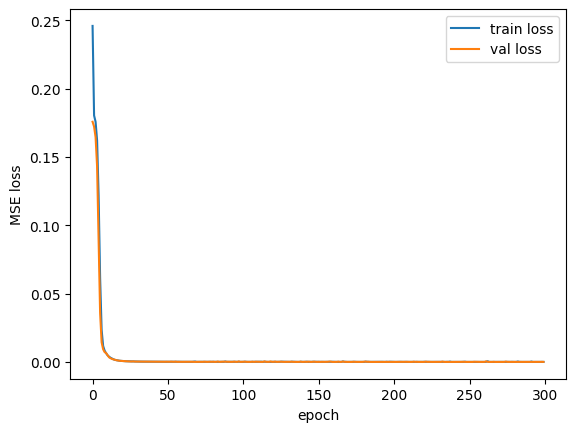

In [5]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()

In [6]:
pred_n = model.predict(X_test, verbose=0).flatten()
y_true_n = Y_test.flatten()

pred = pred_n * y_std + y_mean
y_true = y_true_n * y_std + y_mean

abs_err = np.abs(pred - y_true)
mse = float(np.mean((pred - y_true)**2))
mae = float(np.mean(abs_err))
max_err = float(np.max(abs_err))

print("MSE:", mse)
print("MAE:", mae)
print("Max abs error:", max_err)

MSE: 0.02500486746430397
MAE: 0.11869364976882935
Max abs error: 0.5601959228515625


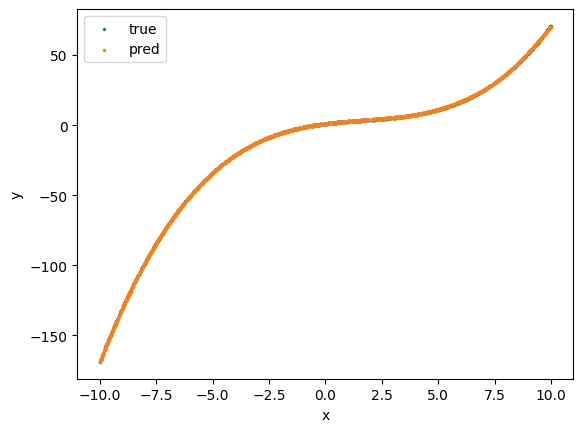

In [8]:
idx = np.random.choice(len(X_test), size=2000, replace=False)

x_plot = X_test[idx].flatten() * x_std + x_mean
y_plot_true = Y_test[idx].flatten() * y_std + y_mean

pred_n_plot = model.predict(X_test[idx], verbose=0).flatten()
y_plot_pred = pred_n_plot * y_std + y_mean

plt.scatter(x_plot, y_plot_true, s=2, label="true")
plt.scatter(x_plot, y_plot_pred, s=2, label="pred")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Resultaten

Het model werd getraind tot convergentie. Hieronder zijn de belangrijkste resultaten weergegeven.

### Interval [-1, 1]
- Mean Absolute Error (MAE): ~0.0007  
- Maximale fout: ~0.0069  
- De voorspelde curve overlapt vrijwel exact met de werkelijke functie.

### Interval [-10, 10]
- Mean Squared Error (MSE): ~0.71  
- Mean Absolute Error (MAE): ~0.65  
- Maximale fout: ~2.35  

Op grotere interval neemt de absolute error toe, met name aan de randen van het bereik waar de helling van de functie groot is. De globale vorm van de functie wordt wel correct geleerd.

## Discussie

De resultaten tonen aan dat het netwerk de globale vorm van de kubische functie wel goed leert. Op kleine intervallen zoals [-1,1] kan het netwerk bijna exact leren, maar op grotere intervallen zoals [-10,10] wordt de absolute error groter, vooral bij steile hellingen.

Dit laat zien dat de schaal van de input en output een grote invloed heeft op de haalbare absolute nauwkeurigheid. Normalisatie is hier voor heel belangrijk.


## Conclusie

Een relatief eenvoudig feedforward neural network met twee verborgen lagen van 128 neuronen is voldoende om een kubische functie nauwkeurig te benaderen.

Vier decimalen absolute nauwkeurigheid is haalbaar op kleine schalen, maar moeilijk op grotere intervallen vanwege schaal en steilheid van de functie. En daardoor niet ideaal voor deze toepassing.
